<a href="https://colab.research.google.com/github/IgorAkO/Simulative_ML/blob/main/4.%20Preprocessing/S_ML_4_Movies_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание
Необходимо предобработать данные о фильмах из предоставленного датасета. Главное – прийти к формату, приемлемому для дальнейшего обучения ML-моделей. Финальный датасет необходимо вывести в конце вашего ноутбука.  
https://www.kaggle.com/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction/data

# Описание датасета Movies
### Context
Данные успешно извлечены из списка лучших фильмов и сериалов на Netflix. Для работы с этим набором данных нужны знания для извлечения признаков. Также вы можете создать систему рекомендаций или модель прогнозирования жанра.
### Content
Набор данных содержит 9 столбцов:  
MOVIES - the movie names  
YEAR  
GENRE  
RATING  
ONE-LINE - the short description  
STARS - participants  
VOTES - the audience view  
RUNTIME - the duration   
GROSS - total earned amount

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import re

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

### 1. Загрузка файла

In [130]:
file_path = "movies.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bharatnatrayn/movies-dataset-for-feature-extracion-prediction",
  file_path,
)

display(df.head(1))
'''
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
#import kagglehub
#from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "movies.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "bharatnatrayn/movies-dataset-for-feature-extracion-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
''';



Using Colab cache for faster access to the 'movies-dataset-for-feature-extracion-prediction' dataset.


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN


### 2. Удаление дублей

In [131]:
# Удаление дублей
print(f'Количество дубликатов: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

Количество дубликатов: 431


In [132]:
# Проверяем количество занятой памяти
bites = sum(df.memory_usage(index=False))
print(f'Таблица занимает: {round(bites/1024/1024, 2)} MB')


Таблица занимает: 0.66 MB


### 3. Фильтрация по малоинформативным столбцам

In [133]:
# Количество уникальных значений близко к длине данных
print(f'Количество строк: {df.shape[0]}')
print(f'Количество уникальных значений "MOVIES": {df.MOVIES.nunique()}')
print(f'Количество уникальных значений "GENRE": {df["GENRE"].nunique()}')
print(f'Количество уникальных значений "ONE-LINE": {df["ONE-LINE"].nunique()}')
print(f'Количество уникальных значений "STARS": {df.STARS.nunique()}')

Количество строк: 9568
Количество уникальных значений "MOVIES": 6817
Количество уникальных значений "GENRE": 510
Количество уникальных значений "ONE-LINE": 8688
Количество уникальных значений "STARS": 7877


In [169]:
# Количество уникальных значений "MOVIES" не 9568, а 6817. o_O
counts = Counter(df['MOVIES']).most_common(3)
display(counts)
df[df['MOVIES'] == ' Bleach: Burîchi'].head(3)

[(' Bleach: Burîchi', 65),
 (' Avatar: The Last Airbender', 61),
 (' La Reina de Indias y el Conquistador', 60)]

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
6536,Bleach: Burîchi,(2004–2012),"\nAnimation, Action, Adventure",8.7,\nCaptain Kurotsushi decides that rather than ...,"\n Directors:\nNoriyuki Abe, \nKazunori Miz...",181,23.0,NaN
6555,Bleach: Burîchi,(2004–2012),"\nAnimation, Action, Adventure",7.9,\nIn order to prove how useless Shinigamis are...,"\n Directors:\nNoriyuki Abe, \nKôji Aritomi...",209,24.0,NaN
6556,Bleach: Burîchi,(2004–2012),"\nAnimation, Action, Adventure",7.7,"\nIchigo runs into Rukia at school, where she'...","\n Directors:\nNoriyuki Abe, \nJun'ya Koshi...",325,24.0,NaN


In [170]:
# Удаляем столбцы c большим количеством уникальных значений
df.drop(['MOVIES'], axis=1, inplace=True)
df.drop(['ONE-LINE'], axis=1, inplace=True)
# Наверно 'STARS' сильно влияют на Rating но их количество слишком уж велико
df.drop(['STARS'], axis=1, inplace=True)

### 4. Удаление пропусков

In [171]:
print(df.isna().sum(), '\n')

YEAR        542
GENRE        78
RATING     1400
VOTES      1400
RunTime    2560
Gross      9108
dtype: int64 



In [172]:
#Существенное количество пропусков в RunTime' и 'Gross'
df.drop(['RunTime'], axis=1, inplace=True)
df.drop(['Gross'], axis=1, inplace=True)
print(df.isna().sum(), '\n')

YEAR       542
GENRE       78
RATING    1400
VOTES     1400
dtype: int64 



In [173]:
# Числвая переменная 'RATING' - ключевой столбец (кандидат на target).
# Если это так, то строки без 'RATING' оказываются неинформативными для модели
# Удаляем строки без 'RATING'
df = df.dropna(subset=['RATING'])
# Другой вариант - заполнение 'RATING'
#df['RATING'] = df['RATING'].fillna(df['RATING'].median())


# Категориальные переменные
df['GENRE'] = df['GENRE'].str.strip()
df['GENRE'] = df['GENRE'].fillna(df['GENRE'].mode()[0])

print(df.isna().sum())
df.head(5)

YEAR      0
GENRE     0
RATING    0
VOTES     0
dtype: int64


,YEAR,GENRE,RATING,VOTES
0,(2021),"Action, Horror, Thriller",6.1,"21,062"
1,(2021– ),"Animation, Action, Adventure",5.0,"17,870"
2,(2010–2022),"Drama, Horror, Thriller",8.2,"885,805"
3,(2013– ),"Animation, Adventure, Comedy",9.2,"414,849"
5,(2020– ),"Action, Crime, Drama",7.6,"25,858"


### 5. Преобразования дат и форматов

In [174]:
df['YEAR'] = df.YEAR.apply(lambda x: re.search(r"\d{4}", x).group()).astype('float64')


df['VOTES'] = df.VOTES.apply(lambda x: x.replace(',', '')).astype('float64')
# Большой разброс в 'VOTES'
min_VOTES = df.VOTES.min()
max_VOTES = df.VOTES.max()
print('Большой разброс в "VOTES":',min_VOTES, max_VOTES)

Большой разброс в "VOTES": 5.0 1713028.0


### 6. Удаление выбросов

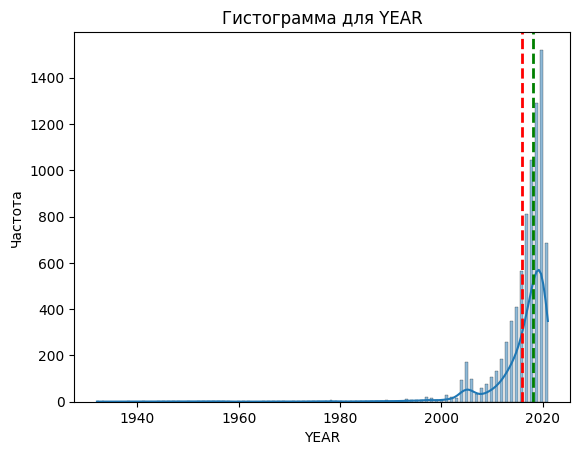

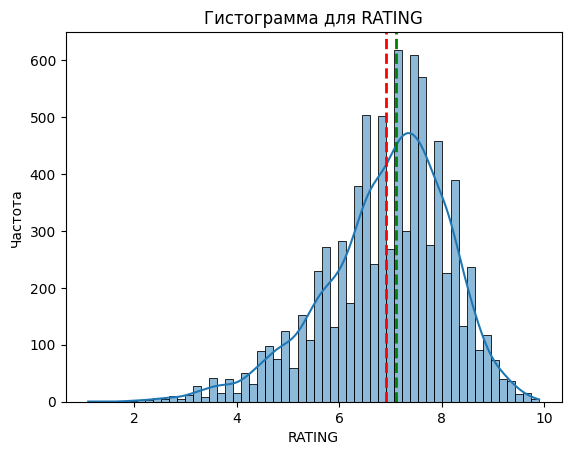

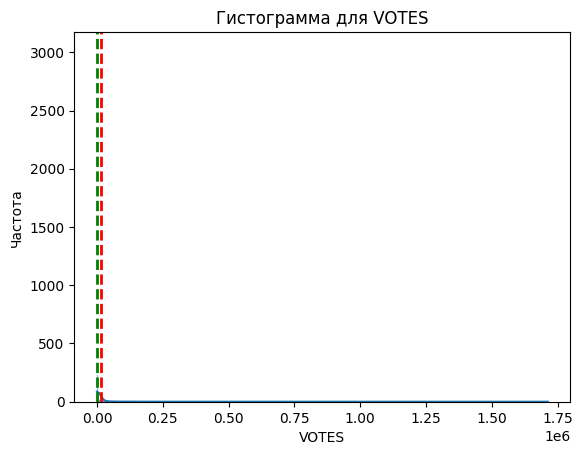

In [176]:
float_col = df.select_dtypes(include='float64').columns
for col in float_col:
  sns.histplot(df[col], kde=True) # kde=True это сглаживание гистограммы

  mean_val = df[col].mean()
  median_val = df[col].median()

  plt.axvline(mean_val, color='red', label=f'Mean {mean_val}', linestyle='dashed', linewidth=2)
  plt.axvline(median_val, color='green', label=f'Median {median_val}', linestyle='dashed', linewidth=2)

  plt.title(f'Гистограмма для {col}')
  plt.xlabel(col)
  plt.ylabel('Частота')
  plt.legend

  plt.show()

In [177]:
for col in float_col:
  print(f'\nСтолбец: {col}')
  print(f'Статистика до:')
  print(df[col].describe(), '\n')

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
  print(f'Статистика после:')
  print(df[col].describe(), '\n')



Столбец: YEAR
Статистика до:
count    8168.000000
mean     2015.832762
std         7.569987
min      1932.000000
25%      2015.000000
50%      2018.000000
75%      2020.000000
max      2021.000000
Name: YEAR, dtype: float64 

Статистика после:
count    7487.000000
mean     2017.520102
std         2.885302
min      2008.000000
25%      2016.000000
50%      2018.000000
75%      2020.000000
max      2021.000000
Name: YEAR, dtype: float64 


Столбец: RATING
Статистика до:
count    7487.000000
mean        6.873514
std         1.206325
min         1.100000
25%         6.200000
50%         7.100000
75%         7.700000
max         9.900000
Name: RATING, dtype: float64 

Статистика после:
count    7320.000000
mean        6.954249
std         1.091145
min         4.000000
25%         6.300000
50%         7.100000
75%         7.700000
max         9.900000
Name: RATING, dtype: float64 


Столбец: VOTES
Статистика до:
count    7.320000e+03
mean     1.206646e+04
std      5.245759e+04
min      5.00

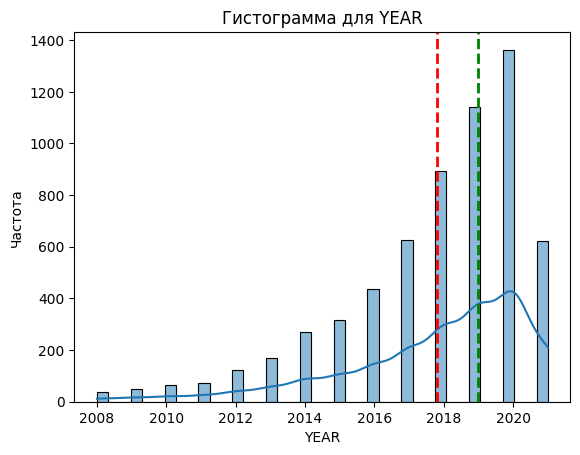

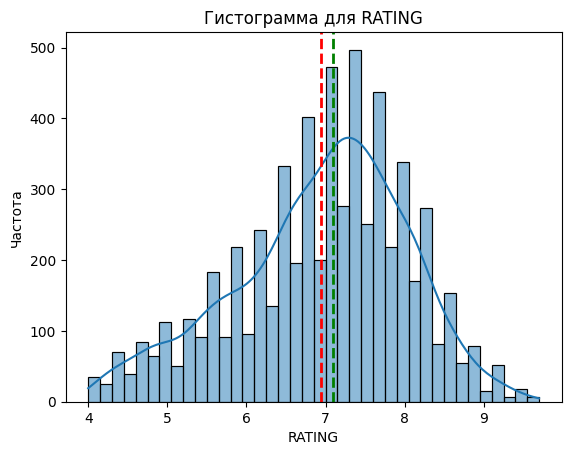

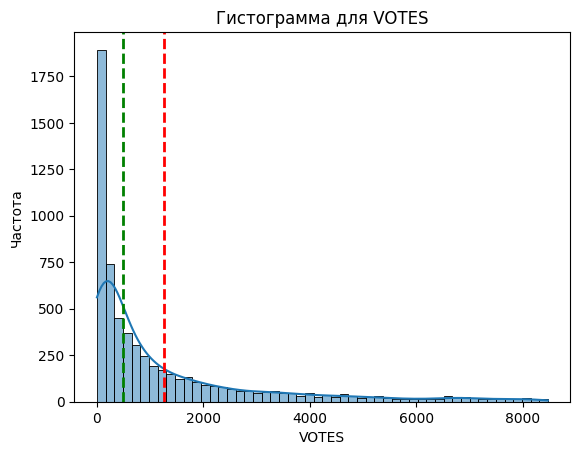

In [178]:
for col in float_col:
  sns.histplot(df[col], kde=True) # kde=True это сглаживание гистограммы

  mean_val = df[col].mean()
  median_val = df[col].median()

  plt.axvline(mean_val, color='red', label=f'Mean {mean_val}', linestyle='dashed', linewidth=2)
  plt.axvline(median_val, color='green', label=f'Median {median_val}', linestyle='dashed', linewidth=2)

  plt.title(f'Гистограмма для {col}')
  plt.xlabel(col)
  plt.ylabel('Частота')
  plt.legend

  plt.show()

### 7.1 Нормировка численных параметров

In [179]:
scaler = {}
for col in float_col:
  min_max_scaler = MinMaxScaler()
  scaler[col] = min_max_scaler
  df[col] = min_max_scaler.fit_transform(df[[col]])

df.head(3)

,YEAR,GENRE,RATING,VOTES
6,1.0,"Drama, Romance",0.491228,0.623803
25,1.0,"Drama, History, Romance",0.175439,0.552653
63,1.0,"Action, Comedy",0.245614,0.307410


### 7.2 Нормировка категориальных параметров

In [180]:
# Приняв 'RATING' за target можно было бы усреднить'GENRE' по target encoding
'''
target_mean = df.groupby('GENRE')['RATING'].mean()
df[target_enc_GENRE] = df['GENRE'].map(target_mean)
df = df.drop(colomns=['GENRE'], axis=1)
''';
# В противном случае множим жанры
print(df.shape)
df = pd.concat([df.drop(columns=['GENRE']), df['GENRE'].str.get_dummies(sep=",")], axis=1)
print(df.shape)
df.head(3)

(6188, 4)
(6188, 53)


,YEAR,RATING,VOTES,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Game-Show,History,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,...,Western,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Game-Show,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War
6,1.0,0.491228,0.623803,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25,1.0,0.175439,0.552653,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
63,1.0,0.245614,0.307410,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 8. Проверка корреляции параметров

In [181]:
corr = df.corr()
#corr

<Axes: >

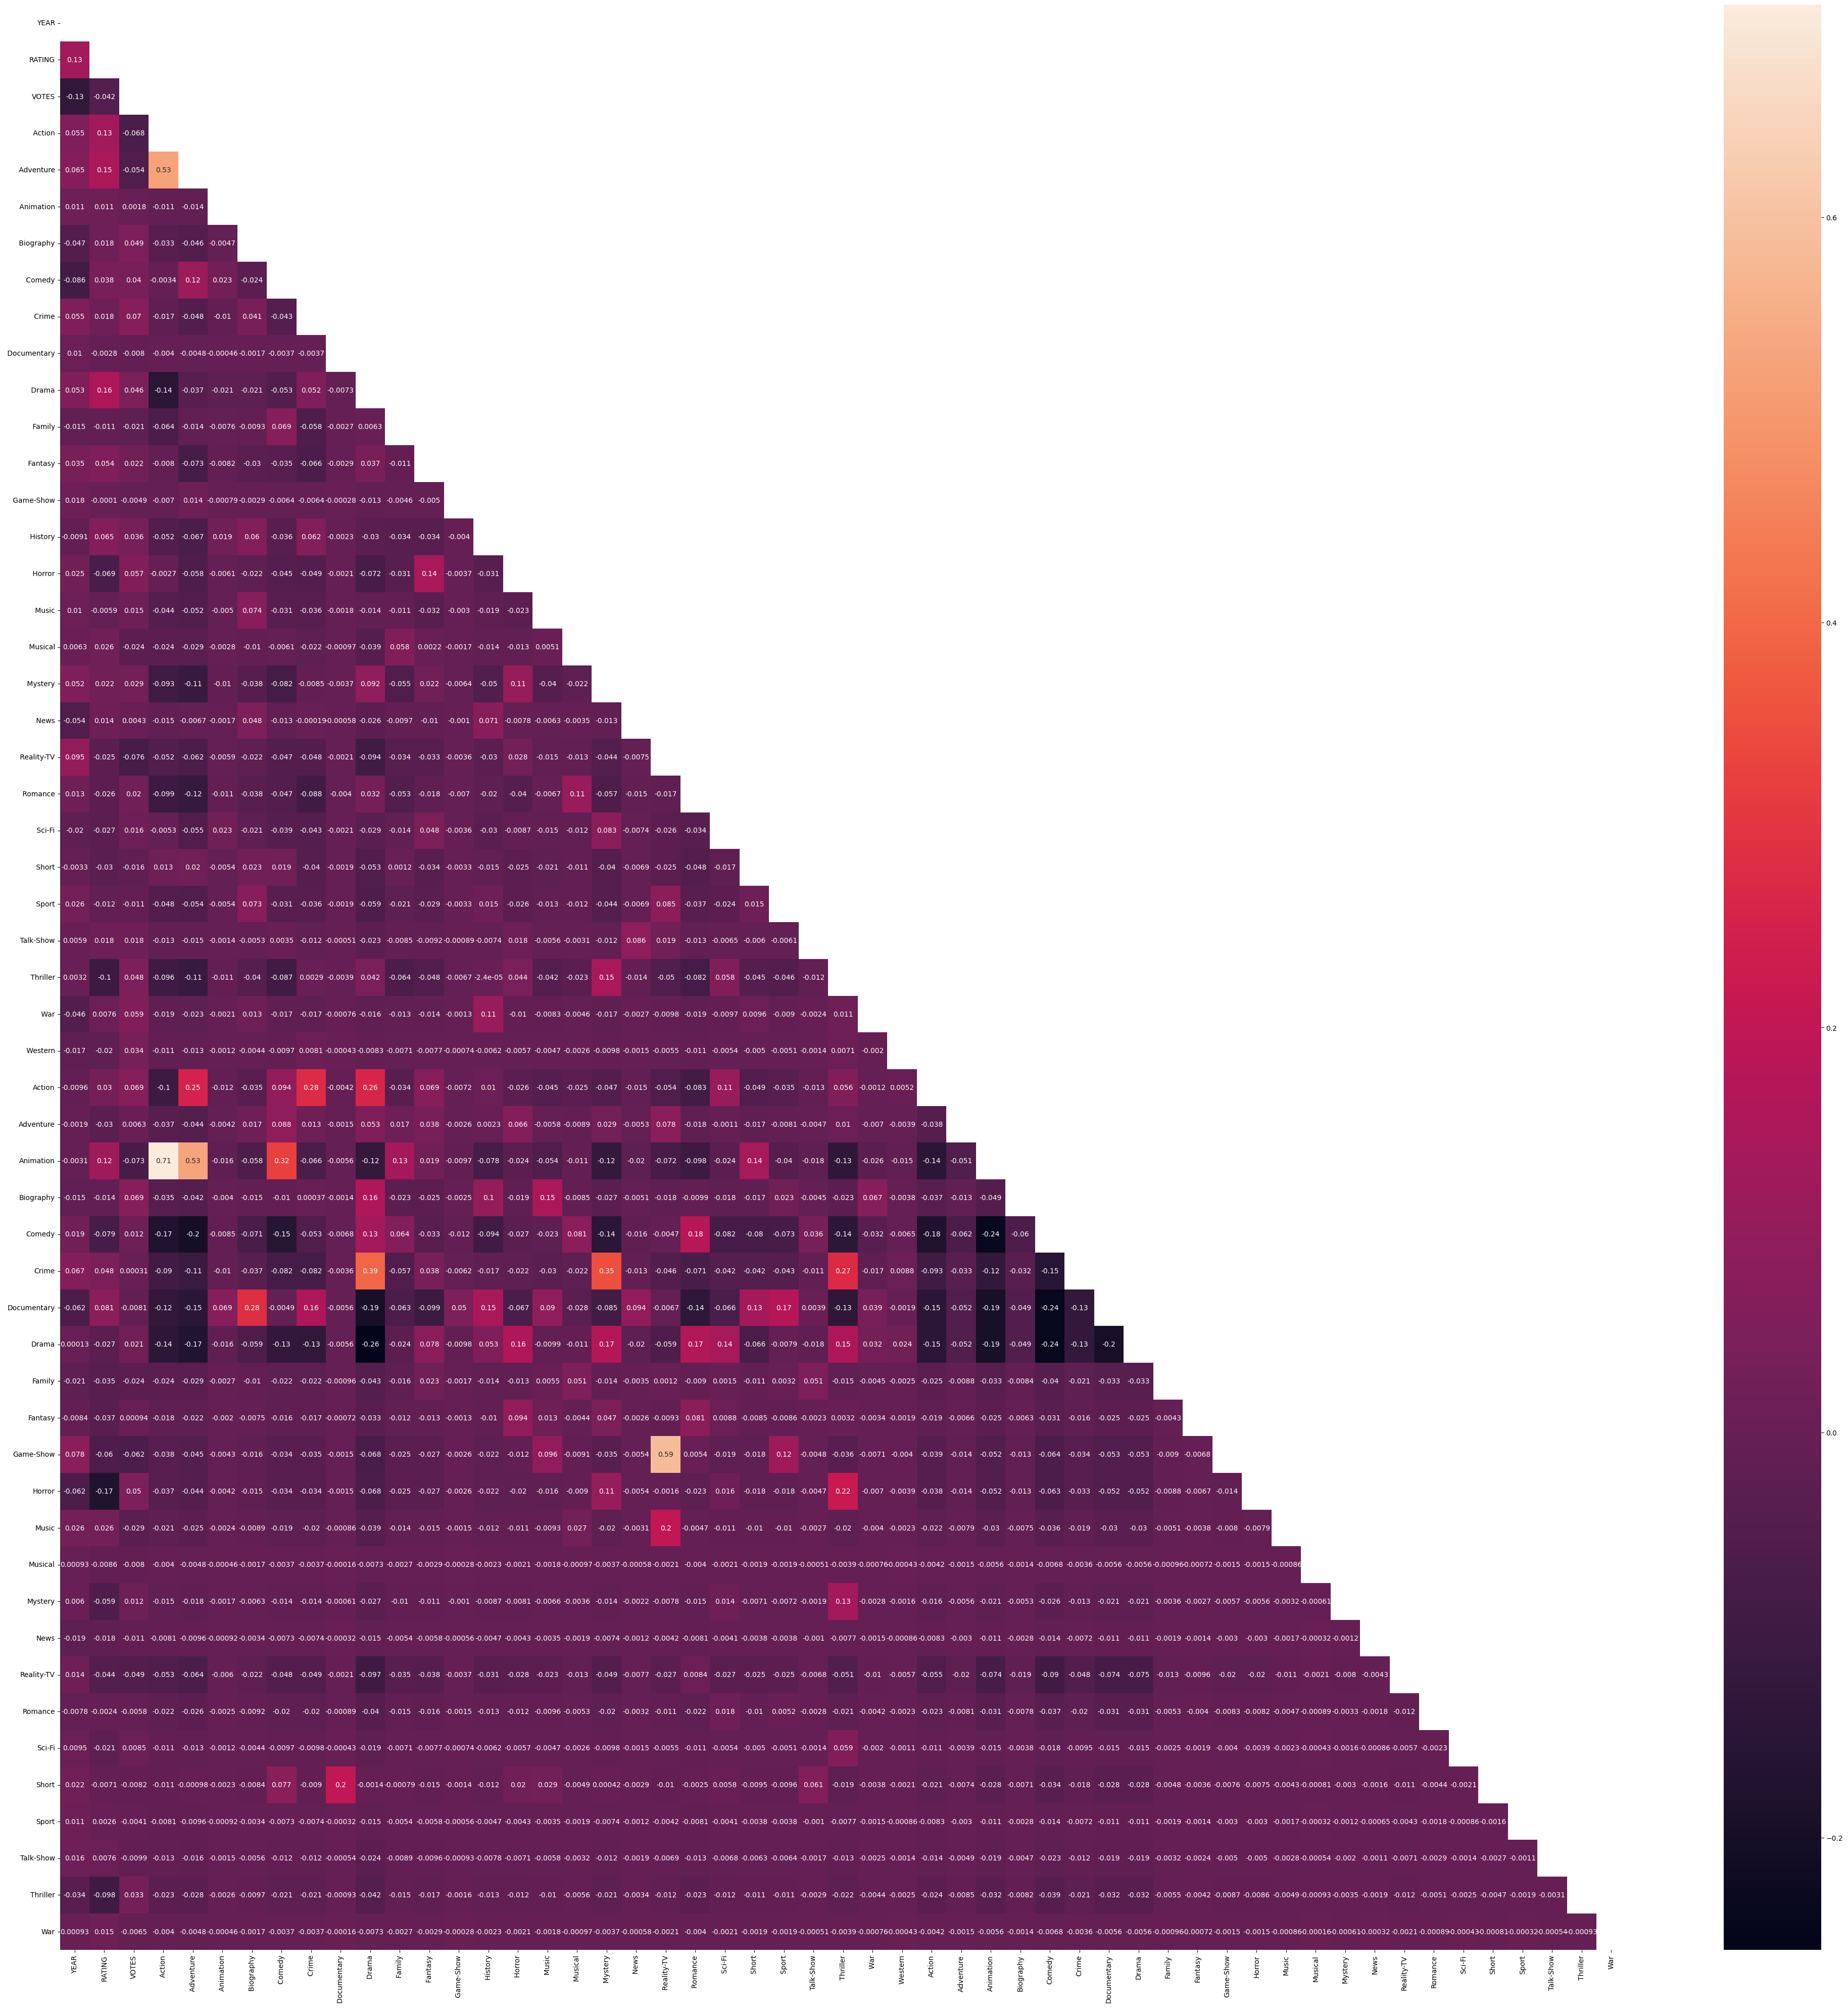

In [182]:
# Берем нижнюю треугольную матрицу
mask = np.triu(np.ones_like(corr, dtype=bool))

# Выводим матрицу корреляций
# figsize для предотвращения слипания
f, ax = plt.subplots(figsize=(50,50))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True)

# Нет параметров с корреляцией > 0.9
# Корреляция 'Action' и 'Animation' составила 0.71

In [183]:
df

,YEAR,RATING,VOTES,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Game-Show,History,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,...,Western,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,Game-Show,Horror,Music,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War
6,1.000000,0.491228,0.623803,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25,1.000000,0.175439,0.552653,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
63,1.000000,0.245614,0.307410,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
64,1.000000,0.298246,0.187448,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
74,1.000000,0.456140,0.099634,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9960,1.000000,0.543860,0.011583,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9961,1.000000,0.508772,0.010755,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9962,1.000000,0.543860,0.011228,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9963,0.692308,0.736842,0.107080,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
